<a href="https://colab.research.google.com/github/Haris-09/Employee-Sentiment-Analysis/blob/main/Employee_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Sentiment Labeling
- Use a pretrained NLP model (e.g., HuggingFace’s transformers with distilbert-base-uncased-finetuned-sst-2-english) or scikit‑learn with TF‑IDF + Logistic Regression.

- Load test.csv.

- Preprocess text (lowercase, remove stopwords, punctuation).

- Apply sentiment classifier → assign labels: Positive, Negative, Neutral.

- Save augmented dataset with a new column Sentiment.

In [ ]:
from transformers import pipeline
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/Haris-09/Employee-Sentiment-Analysis/refs/heads/main/test.csv")
df['date'] = pd.to_datetime(df['date'], errors='coerce')
sentiment_model = pipeline("sentiment-analysis")

df["Sentiment"] = df["body"].apply(lambda x: sentiment_model(x)[0]['label'])

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

## Exploratory Data Analysis (EDA)

- Check dataset structure: missing values, message length distribution.

- Visualizations:

    - Sentiment distribution (bar chart).

    - Sentiment trends over time (line plot).

    - Word clouds for positive vs negative messages

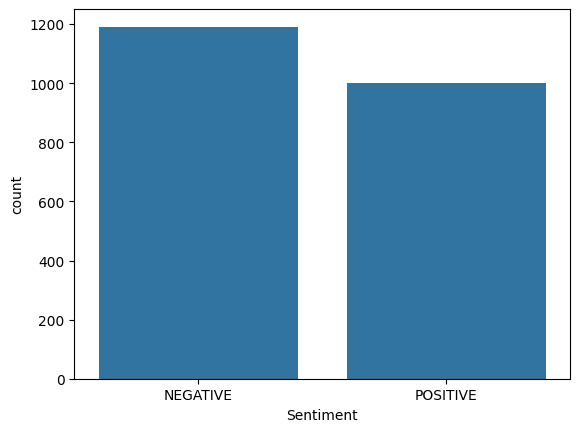

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Sentiment", data=df)
plt.show()

## Employee Score Calculation
- Define scoring: Positive = +1, Negative = -1, Neutral = 0.

- Group by from and year.

- Aggregate scores.

In [ ]:
df["Score"] = df["Sentiment"].map({"POSITIVE":1, "NEGATIVE":-1, "NEUTRAL":0})
yearly_scores = df.groupby(["from",df['date'].dt.year])["Score"].sum().reset_index()

## Employee Ranking
- Sort employees by yearly score.

- Extract Top 3 Positive and Top 3 Negative employees.

In [ ]:
top_positive = yearly_scores.groupby(df['date'].dt.year).apply(lambda x: x.nlargest(3,"Score"))
top_negative = yearly_scores.groupby(df['date'].dt.year).apply(lambda x: x.nsmallest(3,"Score"))

## Flight Risk Identification
-   Flag employees with ≥4 negative messages in any rolling 30‑day window.

-   Use a rolling count per employee.

In [ ]:
df["NegativeFlag"] = (df["Sentiment"]=="NEGATIVE").astype(int)
flight_risk = df.groupby(["from",df['date'].dt.year])["NegativeFlag"].sum()
risk_employees = flight_risk[flight_risk >= 4].index

## Predictive Modeling
-   Features: from, yearly scores.

-   Target: yearly sentiment score.

-   Train/test split → Linear Regression.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_encoded = pd.get_dummies(yearly_scores["from"], prefix='from')

X = pd.concat([X_encoded, yearly_scores["date"]], axis=1)
y = yearly_scores["Score"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = LinearRegression().fit(X_train,y_train)

r_squared = model.score(X_test, y_test)
print(f"R-squared score: {r_squared:.2f}")


R-squared score: -2.04
